In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import common



In [2]:
CSV_PATH = f"{common.CONFIG['paths']['raw_data']}/{common.CONFIG['dataset']['csv_file']}"


In [3]:
data = pd.read_csv(CSV_PATH)


In [4]:
# display table dimensions
print(data.shape)

(1458644, 11)


In [5]:
# display 10 random rows
print(data.sample(10))

                id  vendor_id      pickup_datetime     dropoff_datetime  \
895316   id1674998          2  2016-06-09 00:14:22  2016-06-09 00:21:01   
1001828  id1128998          2  2016-03-21 20:31:10  2016-03-21 20:38:40   
988924   id0789377          2  2016-02-15 20:32:33  2016-02-15 20:48:07   
872244   id0308985          1  2016-05-14 10:05:50  2016-05-14 10:14:22   
223521   id0555507          1  2016-05-31 07:24:05  2016-05-31 07:31:15   
630107   id1499532          2  2016-04-11 09:47:22  2016-04-11 09:56:21   
87922    id3041809          2  2016-03-21 08:42:51  2016-03-21 08:47:17   
62014    id0719500          2  2016-01-10 00:52:20  2016-01-10 00:57:40   
1200917  id1236232          1  2016-02-16 14:09:50  2016-02-16 14:14:32   
247394   id3653495          2  2016-06-30 18:29:25  2016-06-30 18:41:56   

         passenger_count  pickup_longitude  pickup_latitude  \
895316                 1        -73.975456        40.741001   
1001828                2        -73.990875      

In [6]:
# display descriptive statistics
print(data.describe())
print(data.describe(include="object"))

          vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count  1.458644e+06     1.458644e+06      1.458644e+06     1.458644e+06   
mean   1.534950e+00     1.664530e+00     -7.397349e+01     4.075092e+01   
std    4.987772e-01     1.314242e+00      7.090186e-02     3.288119e-02   
min    1.000000e+00     0.000000e+00     -1.219333e+02     3.435970e+01   
25%    1.000000e+00     1.000000e+00     -7.399187e+01     4.073735e+01   
50%    2.000000e+00     1.000000e+00     -7.398174e+01     4.075410e+01   
75%    2.000000e+00     2.000000e+00     -7.396733e+01     4.076836e+01   
max    2.000000e+00     9.000000e+00     -6.133553e+01     5.188108e+01   

       dropoff_longitude  dropoff_latitude  trip_duration  
count       1.458644e+06      1.458644e+06   1.458644e+06  
mean       -7.397342e+01      4.075180e+01   9.594923e+02  
std         7.064327e-02      3.589056e-02   5.237432e+03  
min        -1.219333e+02      3.218114e+01   1.000000e+00  
25%        -7.399133e+01

C:\Users\lmanuelli\AppData\Local\Temp\ipykernel_44692\3317148200.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include="object"))


               id      pickup_datetime     dropoff_datetime store_and_fwd_flag
count     1458644              1458644              1458644            1458644
unique    1458644              1380222              1380377                  2
top     id2875421  2016-04-05 18:55:21  2016-05-16 19:40:28                  N
freq            1                    5                    5            1450599


In [7]:
# check if there are any columns containing unique values for each row. If so, drop them.
data = data.drop(columns=["id"])

In [8]:
# dropoff_datetime variable is added only to train data and thus cannot be used by the predictive model.
data = data.drop(columns=["dropoff_datetime"])

In [9]:
# pickup_datetime contains date and time when the meter was engaged.
print(data["pickup_datetime"].dtype)
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"])
print(data["pickup_datetime"].head())

str
0   2016-03-14 17:24:55
1   2016-06-12 00:43:35
2   2016-01-19 11:35:24
3   2016-04-06 19:32:31
4   2016-03-26 13:30:55
Name: pickup_datetime, dtype: datetime64[us]


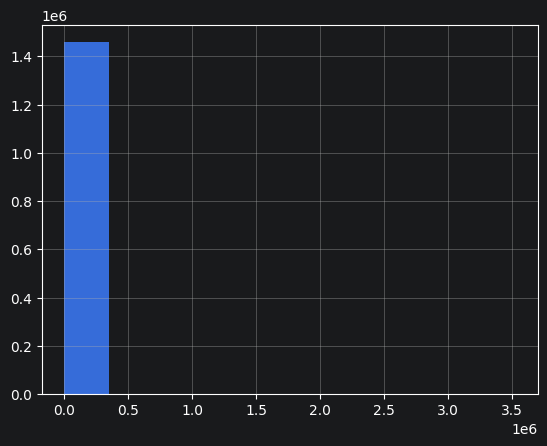

In [10]:
# Check the distribution of the target variable values.
data.trip_duration.hist()
plt.show()
